# cic-ids2017 — offline benchmark (RandomForest vs XGBoost vs MLP)
public benchmark on **CIC-IDS2017** (abluva/CIC-IDS-2017-V2), 40k balanced rows,
**78 flow features**, mapped to our 5 classes. three models compared; XGBoost on the RTX 3070.
*offline* benchmark — the board runs our own 6-feature model (`train.ipynb`).

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score)
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('cic_slice.csv').replace([np.inf,-np.inf], np.nan).fillna(0)
FEATURES = [c for c in df.columns if c != 'label']
print('rows', len(df), '| features', len(FEATURES))
print(df['label'].value_counts().to_string())

rows 40000 | features 78
label
bruteforce    8000
flood         8000
normal        8000
scan          8000
slowloris     8000


## detect GPU + prepare data (split + scale)

In [2]:
try:
    xgb.XGBClassifier(n_estimators=2, tree_method='hist', device='cuda').fit(
        np.zeros((4,2),'float32'), [0,1,0,1])
    DEVICE = 'cuda'
except Exception:
    DEVICE = 'cpu'
print('xgboost device:', DEVICE)

X = df[FEATURES].to_numpy(dtype=float)
le = LabelEncoder().fit(df['label'].astype(str).to_numpy())
y = le.transform(df['label'].astype(str).to_numpy())
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)   # MLP needs scaling
print('train', Xtr.shape, ' test', Xte.shape, ' classes', list(le.classes_))

xgboost device: cuda
train (28000, 78)  test (12000, 78)  classes ['bruteforce', 'flood', 'normal', 'scan', 'slowloris']


## three models head-to-head — RandomForest vs XGBoost (GPU) vs MLP

In [3]:
res = {}
t=time.time(); rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0).fit(Xtr, ytr)
res['RandomForest'] = (accuracy_score(yte, rf.predict(Xte)), time.time()-t, '16 cores')
t=time.time(); xg = xgb.XGBClassifier(n_estimators=300, tree_method='hist', device=DEVICE, random_state=0).fit(Xtr, ytr)
res['XGBoost'] = (accuracy_score(yte, xg.predict(Xte)), time.time()-t, DEVICE)
t=time.time(); mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=0).fit(Xtr_s, ytr)
res['MLP'] = (accuracy_score(yte, mlp.predict(Xte_s)), time.time()-t, 'cpu')
print(f"{'model':14}{'accuracy':>10}{'train':>9}   hardware")
for k,(a,tt,hw) in res.items(): print(f'{k:14}{a:>10.4f}{tt:>8.1f}s   {hw}')

model           accuracy    train   hardware
RandomForest      0.9977     1.0s   16 cores
XGBoost           0.9988     1.5s   cuda
MLP               0.9939     5.1s   cpu


## XGBoost — report + confusion matrix

XGBoost test accuracy: 0.9988
              precision    recall  f1-score   support

  bruteforce       1.00      1.00      1.00      2400
       flood       1.00      1.00      1.00      2400
      normal       1.00      1.00      1.00      2400
        scan       1.00      1.00      1.00      2400
   slowloris       1.00      1.00      1.00      2400

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



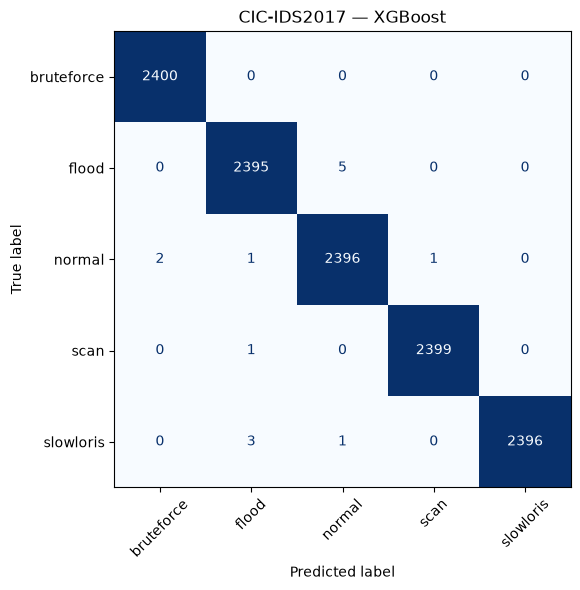

In [4]:
pred = xg.predict(Xte)
print('XGBoost test accuracy:', round(accuracy_score(yte, pred), 4))
print(classification_report(yte, pred, target_names=le.classes_))
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=le.classes_).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('CIC-IDS2017 — XGBoost'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## MLP — report + confusion matrix (tested on CIC too)

MLP test accuracy: 0.9939


              precision    recall  f1-score   support

  bruteforce       1.00      1.00      1.00      2400
       flood       0.99      0.99      0.99      2400
      normal       0.99      0.99      0.99      2400
        scan       1.00      1.00      1.00      2400
   slowloris       1.00      0.99      1.00      2400

    accuracy                           0.99     12000
   macro avg       0.99      0.99      0.99     12000
weighted avg       0.99      0.99      0.99     12000



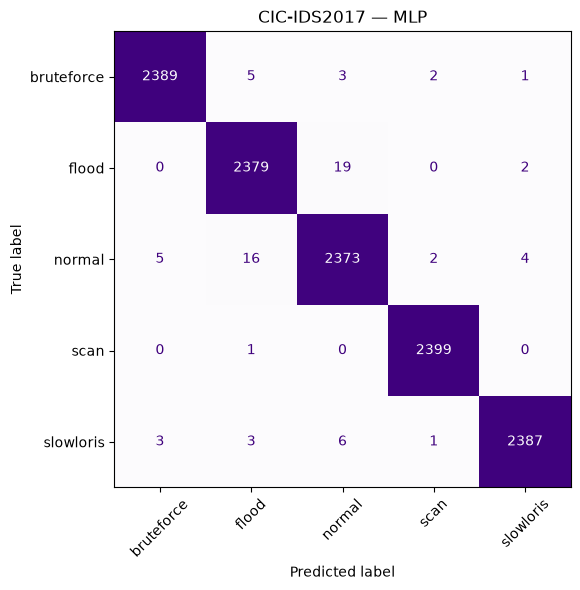

In [5]:
predm = mlp.predict(Xte_s)
print('MLP test accuracy:', round(accuracy_score(yte, predm), 4))
print(classification_report(yte, predm, target_names=le.classes_))
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(confusion_matrix(yte, predm), display_labels=le.classes_).plot(ax=ax, cmap='Purples', colorbar=False)
plt.title('CIC-IDS2017 — MLP'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## top flow features (XGBoost importance)

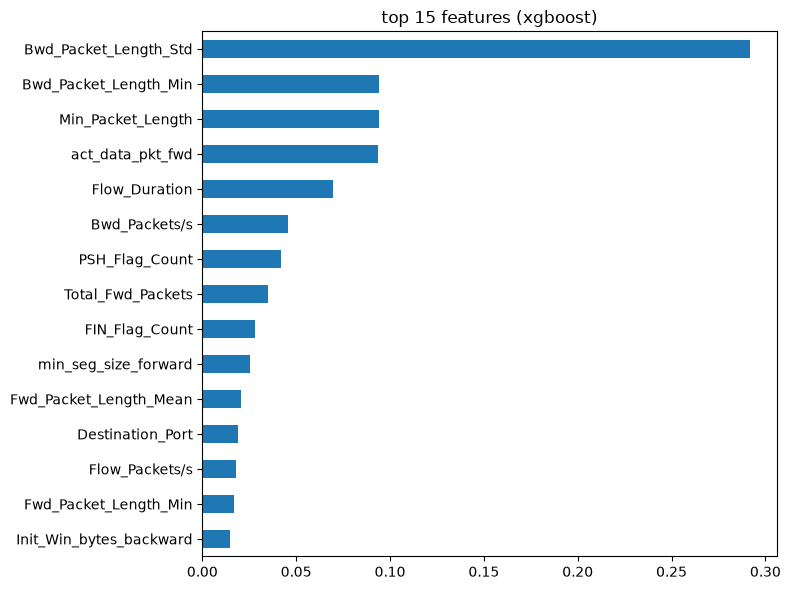

In [6]:
imp = pd.Series(xg.feature_importances_, index=FEATURES).sort_values()[-15:]
plt.figure(figsize=(8,6)); imp.plot.barh()
plt.title('top 15 features (xgboost)'); plt.tight_layout(); plt.show()

## takeaway
- three strong models on **CIC-IDS2017** (78 flow features) — XGBoost (GPU), RandomForest, MLP.
- all near-perfect; **XGBoost** is the headline benchmark.
- these 78 features can't be computed live on the board, so the **on-board model is our own
  6-feature one** (`train.ipynb`). benchmark = credibility; small model = the edge.